<div style='font-size:14px'> now we will learn customising all the plots so for first half we will discuss the line charts and then we will discuss all the different parameters that we can adjust in order to make our visualisations pop more. And for 2nd part we will discuss scatter plots

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
import numpy as np
import ast

# Loading Data set
dataset= load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# cleanup
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

# Filter for Data Analyst data
df_DA = df[df['job_title_short'] == 'Data Analyst'].copy()

<div style='font-size:14px'>now we will be working on the chart we created in ex 12 in pandas

In [ ]:
df_DA['job_posted_month_no']=df['job_posted_date'].dt.month

In [ ]:
df_DA_explode = df_DA.explode('job_skills')

In [13]:
df_DA_pivot = df_DA_explode.pivot_table(
    index='job_posted_month_no',
    columns='job_skills',
    aggfunc='size',
    fill_value=0
).copy()

In [14]:
df_DA_pivot.loc['Total'] = df_DA_pivot.sum()

In [15]:
df_DA_pivot = df_DA_pivot[df_DA_pivot.loc['Total'].sort_values(ascending=False).index]

In [16]:
df_DA_pivot.drop('Total',inplace=True)

In [19]:
# use month name for plotting
df_DA_pivot = df_DA_pivot.reset_index()

In [22]:
df_DA_pivot['job_posted_month'] = df_DA_pivot['job_posted_month_no'].apply(lambda x:pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_pivot = df_DA_pivot.set_index('job_posted_month')
df_DA_pivot = df_DA_pivot.drop(columns='job_posted_month_no')

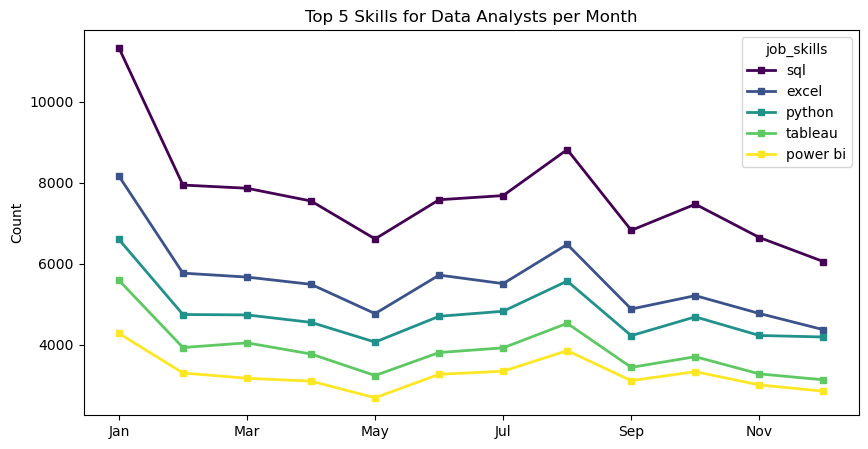

In [50]:
df_DA_pivot.iloc[:,:5].plot(
    kind='line',
    linewidth=2,
    linestyle='-', #options: '-','--','-.',':'
    colormap='viridis' ,#for more color maps refer to cheatsheet
    marker='s', #options: 'o',"x","+","*","s",",",".","1","2","3","4"
    markersize=5,
    figsize=(10,5) # figsize(width, height)
    )

plt.title('Top 5 Skills for Data Analysts per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

Customising Scatte Plot from last file

In [55]:
skills_stats = df_DA_explode.groupby('job_skills').agg(
    skill_count=('job_skills','count'),
    median_salary=('salary_year_avg','median')
)

skill_count = 20
skills_stats = skills_stats.sort_values(by='skill_count',ascending=False).head(skill_count)

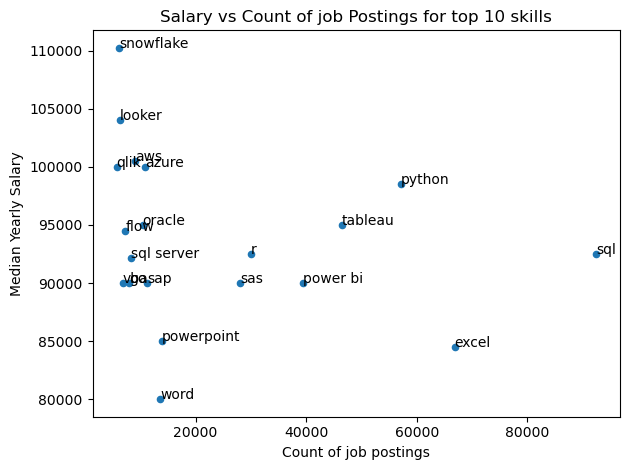

In [56]:
skills_stats.plot(kind='scatter',x='skill_count',y='median_salary')
plt.xlabel('Count of job postings')
plt.ylabel('Median Yearly Salary')
plt.title('Salary vs Count of job Postings for top 10 skills')
plt.tight_layout()

for i, txt in enumerate(skills_stats.index):
    plt.text(skills_stats['skill_count'].iloc[i],skills_stats['median_salary'].iloc[i],txt)

<div style='font-size:14px'>now in order to handle this overlapping mess we will be using adjusttext.AdjustText is a Python library used to automatically adjust the position of text labels in Matplotlib plots, minimizing overlaps between labels, data points, and other plot objects.You can follow its documentation. we need to parameters- texts (list) – A list of matplotlib.text.Text objects to adjust. 

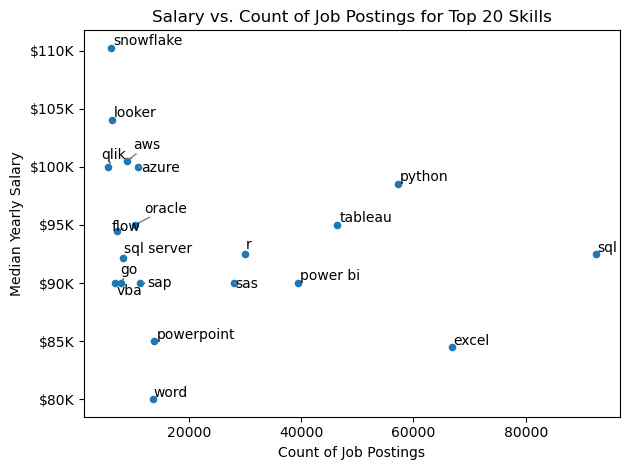

In [74]:
from adjustText import adjust_text

skills_stats.plot(kind='scatter',x='skill_count',y='median_salary')
plt.xlabel('Count of job postings')
plt.ylabel('Median Yearly Salary')
plt.title('Salary vs Count of job Postings for top 10 skills')
plt.tight_layout()

texts = []
for i, txt in enumerate(skills_stats.index):
    texts.append(plt.text(skills_stats['skill_count'].iloc[i],skills_stats['median_salary'].iloc[i],txt))

adjust_text(texts,arrowprops=dict(arrowstyle='->', color='gray', lw=1))

# now we need to modify axises also so first we will access the axis using gca we will write gca code after plotting else it will replace the plotted graph and shows blank graph
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary')
plt.title(f'Salary vs. Count of Job Postings for Top {skill_count} Skills')
plt.tight_layout()
plt.show()
